# Show2D — Large Image Stress Test (#75)
Verify that large images (2048×2048+) display without blocking.
The static PNG fallback is downsampled to 256px max — interactive widget keeps full resolution.

In [22]:
try:
    %load_ext autoreload
    %autoreload 2
    %env ANYWIDGET_HMR=1
except Exception:
    pass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: ANYWIDGET_HMR=1


In [23]:
import numpy as np
import torch
import time
from quantem.widget import Show2D, profile
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
def make_em_image(h, w, seed=0):
    """Asymmetric EM-like image with clear orientation (bright top-left corner)."""
    rng = np.random.default_rng(seed)
    y, x = torch.meshgrid(
        torch.arange(h, device=device, dtype=torch.float32),
        torch.arange(w, device=device, dtype=torch.float32), indexing="ij")
    img = (1.0 - y / h) * 2.0
    mask = ((y < h * 0.4) & (x < w * 0.35)).float()
    img = img + mask * 3.0
    angle = np.radians(seed * 15)
    img = img + torch.cos(2 * np.pi * 0.03 * (x * np.cos(angle) + y * np.sin(angle)))
    noise = torch.from_numpy(rng.normal(0, 0.15, (h, w)).astype(np.float32)).to(device)
    return (img + noise).cpu().numpy()
profile()

## Single 2048×2048

Init: 0.232s  |  shape: (2048, 2048)


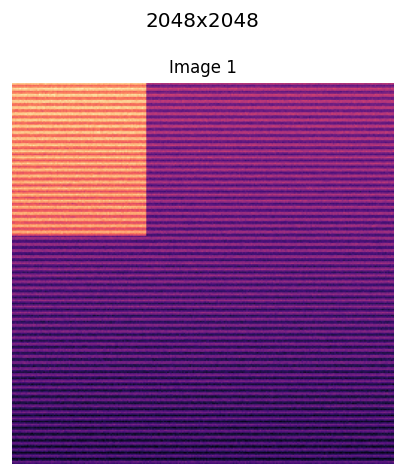

In [24]:
big = make_em_image(2048, 2048, seed=42)
t0 = time.perf_counter()
w = Show2D(big, title="2048x2048", cmap="magma")
t1 = time.perf_counter()
print(f"Init: {t1-t0:.3f}s  |  shape: {big.shape}")
w

## Gallery 4× 2048×2048

Init: 0.765s


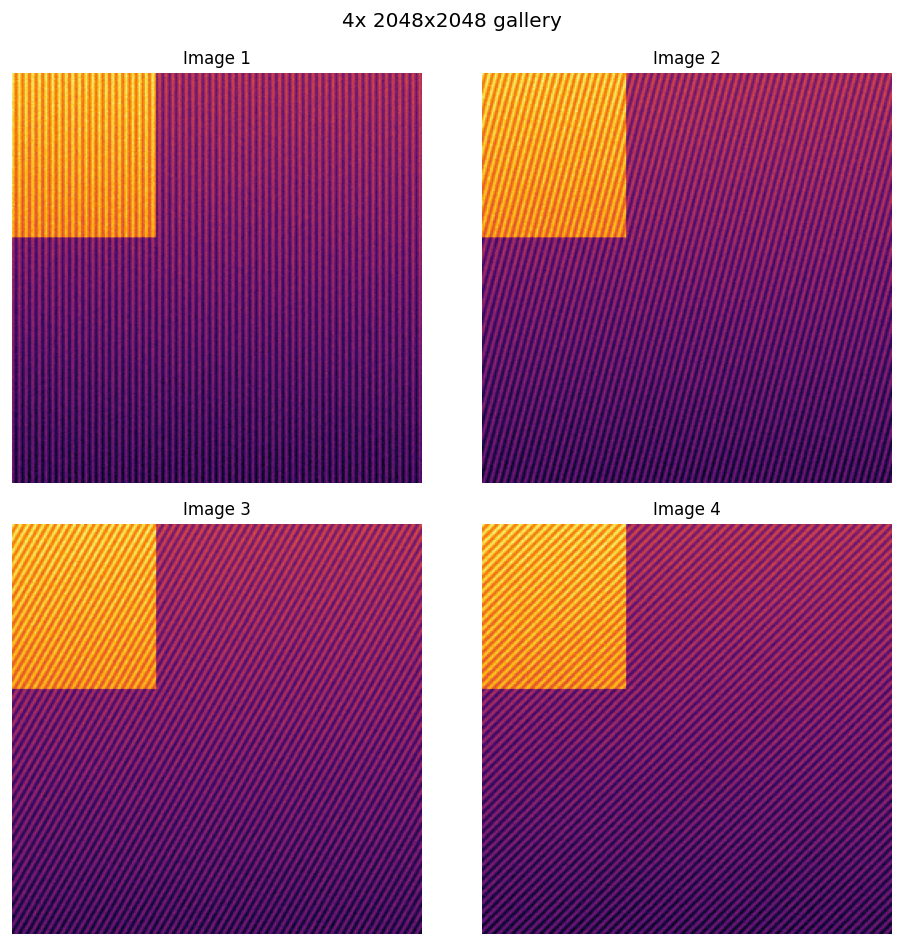

In [25]:
imgs = [make_em_image(2048, 2048, seed=i) for i in range(4)]
t0 = time.perf_counter()
w2 = Show2D(imgs, title="4x 2048x2048 gallery", cmap="inferno", ncols=2)
t1 = time.perf_counter()
print(f"Init: {t1-t0:.3f}s")
w2

## Single 4096×4096

Init: 1.113s  |  shape: (4096, 4096)
⚠️  FFT on this image will be slow — expect a warning.


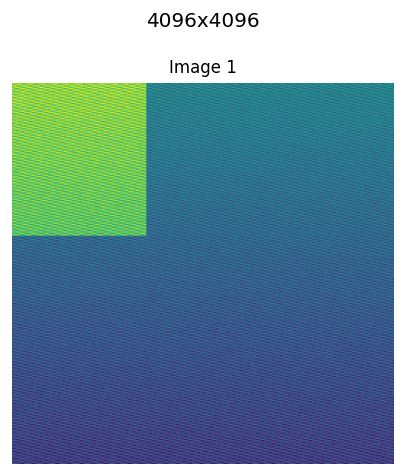

In [26]:
huge = make_em_image(4096, 4096, seed=7)
t0 = time.perf_counter()
w3 = Show2D(huge, title="4096x4096", cmap="viridis")
t1 = time.perf_counter()
print(f"Init: {t1-t0:.3f}s  |  shape: {huge.shape}")
print("⚠️  FFT on this image will be slow — expect a warning.")
w3

## ROI + FFT Stress Test (2048×2048)
Enable FFT, add an ROI, then drag the ROI around.
FFT recomputes in real-time during drag using the rAF generation counter pattern —
rapid drag events coalesce to ≤1 FFT per display frame, and the browser paints the
ROI position update before each FFT runs.

In [27]:
roi_test = make_em_image(2048, 2048, seed=99)
w4 = Show2D(roi_test, title="ROI+FFT drag test (2048x2048)", cmap="inferno",
            show_fft=True, roi_active=True)
w4.add_roi(row=1024, col=1024, radius=256, shape="circle")
print("Drag the ROI around — FFT should update only on mouse release, not during drag.")
w4

TypeError: Show2D.add_roi() got an unexpected keyword argument 'radius'

## ROI + FFT Stress Test (4096×4096)
Same test with a 4096×4096 image — maximum stress on the FFT pipeline.
The rAF pattern ensures smooth ROI drag even when individual FFT computations are slow.

In [ ]:
roi_test_4k = make_em_image(4096, 4096, seed=55)
w5 = Show2D(roi_test_4k, title="ROI+FFT drag test (4096x4096)", cmap="magma",
            show_fft=True, roi_active=True)
w5.add_roi(row=2048, col=2048, radius=512, shape="circle")
print("Drag the ROI — FFT deferred during drag, recomputes on release.")
w5

## ROI Resize + FFT (2048×2048)
Resize the ROI handle while FFT is on — tests the `isDraggingResize` path.

In [ ]:
roi_resize = make_em_image(2048, 2048, seed=77)
w6 = Show2D(roi_resize, title="ROI resize+FFT test (2048x2048)", cmap="viridis",
            show_fft=True, roi_active=True)
w6.add_roi(row=1024, col=1024, radius=200, shape="square")
print("Drag the ROI resize handle — FFT deferred during resize.")
w6